In [1]:
import wrds

# db = wrds.Connection(wrds_username='changjulian17')
db = wrds.Connection()

KeyboardInterrupt: Interrupted by user

In [16]:
data = db.raw_sql("""
    SELECT
        date,
        time_m,
        time_m_nano,
        ex,
        sym_root,
        sym_suffix,
        bid,
        bidsiz,
        ask,
        asksiz,
        qu_cond,
        qu_seqnum,
        natbbo_ind,
        qu_cancel,
        qu_source,
        rpi,
        ssr,
        luld_bbo_indicator,
        finra_bbo_ind,
        finra_adf_mpid,
        finra_adf_time,
        finra_adf_time_nano,
        finra_adf_mpq_ind,
        finra_adf_mquo_ind,
        sip_message_id,
        natl_bbo_luld,
        part_time,
        part_time_nano,
        secstat_ind
    FROM taqm_2023.cqm_2023
    WHERE sym_root IN ('FTAI', 'WLFC', 'HEES', 'AL', 'GATX', 'ALTG')
      AND ex IN ('Q', 'N')
      AND date BETWEEN '2023-05-10' AND '2023-05-11'
      AND time_m BETWEEN '09:30:00' AND '16:00:00'
""")


In [17]:
import polars as pl

In [18]:
data = pl.from_pandas(data)

In [23]:
data['sym_root'].value_counts().sort(by='count', descending=True)

sym_root,count
str,u32
"""AL""",87751
"""FTAI""",26359
"""GATX""",17800
"""ALTG""",13533
"""HEES""",8566
"""WLFC""",2397


In [25]:
data['qu_cancel'].value_counts().sort(by='count', descending=True)

qu_cancel,count
str,u32
null,156406


In [31]:
data['qu_cond'].value_counts().sort(by='count', descending=True)

qu_cond,count
str,u32
"""R""",156396
"""O""",10


In [26]:
data[['bid', 'bidsiz', 'ask', 'asksiz']].describe()

statistic,bid,bidsiz,ask,asksiz
str,f64,f64,f64,f64
"""count""",156406.0,156406.0,156406.0,156406.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",42.226202,2.06276,42.367918,2.347295
"""std""",25.845435,2.052715,25.946198,2.753944
"""min""",0.0,0.0,0.0,0.0
"""25%""",27.85,1.0,27.97,1.0
"""50%""",37.81,1.0,37.88,2.0
"""75%""",38.12,2.0,38.17,3.0
"""max""",112.53,64.0,117.0,205.0


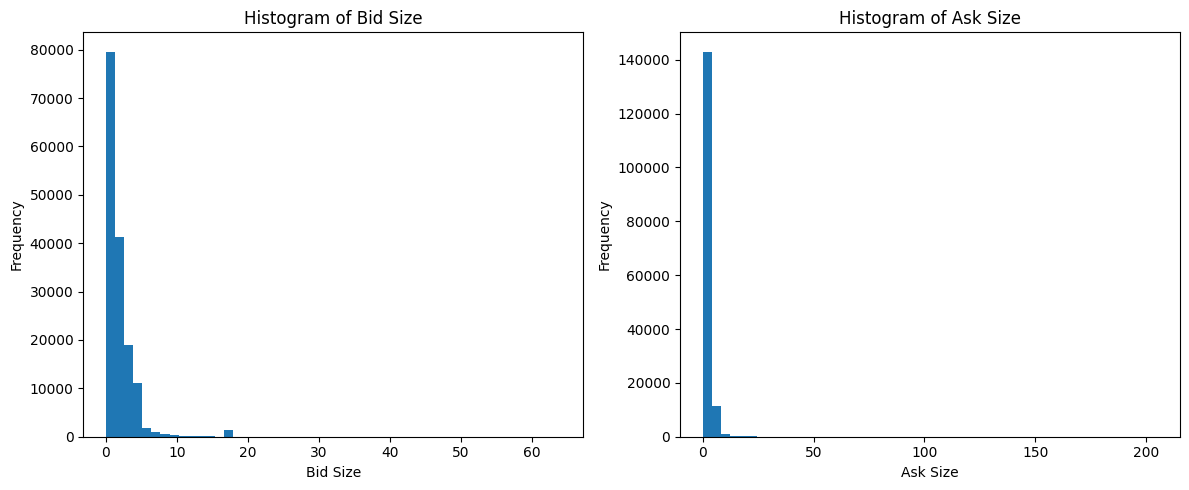

In [30]:
import matplotlib.pyplot as plt

# Convert to pandas if not already
pdf = data.to_pandas()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(pdf['bidsiz'].dropna(), bins=50)
plt.title('Histogram of Bid Size')
plt.xlabel('Bid Size')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(pdf['asksiz'].dropna(), bins=50)
plt.title('Histogram of Ask Size')
plt.xlabel('Ask Size')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [3]:
import polars as pl

df = pl.DataFrame({
    "time_m": ["12:34:56", "12:34:56.1", "12:34:56.123456"]
})

# Apply replacement to pad microseconds
df = df.with_columns(
    pl.col("time_m")
    .str.replace(r"^(\d{2}:\d{2}:\d{2})$", r"$1.000000")  # append .000000 if missing
    .alias("time_m_fixed")
)

print(df)


shape: (3, 2)
┌─────────────────┬─────────────────┐
│ time_m          ┆ time_m_fixed    │
│ ---             ┆ ---             │
│ str             ┆ str             │
╞═════════════════╪═════════════════╡
│ 12:34:56        ┆ 12:34:56.000000 │
│ 12:34:56.1      ┆ 12:34:56.1      │
│ 12:34:56.123456 ┆ 12:34:56.123456 │
└─────────────────┴─────────────────┘
